# 🎓 University Admission Prediction — End-to-End Regression Project

---

| Detail | Info |
|--------|------|
| **Domain** | Education / Predictive Analytics |
| **Problem Type** | Regression (Predict continuous probability 0–1) |
| **Dataset** | Graduate Admissions — 500 student records |
| **Target Variable** | `Chance of Admit` (0.0 to 1.0) |
| **Best Model** | Linear Regression / Ridge Regression |
| **Best R² Score** | ~82–85% |
| **Algorithms Tested** | 9 (Linear, Polynomial, Lasso, Ridge, ElasticNet, SVR, DT, RF, GBR, XGB) |

---

## 🎯 Business Objective

> Help students **understand their chances of getting admitted** to a graduate university based on their academic profile — enabling better preparation, realistic goal-setting, and smarter university shortlisting.

**Key Questions Answered:**
- Which factors most strongly predict admission chances?
- Can we predict a student's admission probability from test scores and GPA?
- Which ML model gives the most accurate and generalisable predictions?

---

## 📖 Features Overview

| Feature | Type | Description |
|---------|------|-------------|
| `GRE Score` | Continuous | Graduate Record Exam score (260–340) |
| `TOEFL Score` | Continuous | English proficiency test score (0–120) |
| `University Rating` | Ordinal | University prestige rating (1–5) |
| `SOP` | Ordinal | Statement of Purpose strength (1.0–5.0) |
| `LOR` | Ordinal | Letter of Recommendation strength (1.0–5.0) |
| `CGPA` | Continuous | Undergraduate GPA (out of 10) |
| `Research` | Binary | Research experience (0=No, 1=Yes) |
| `Chance of Admit` | **Target** | Admission probability (0.0–1.0) |

---

## 🗺️ Project Workflow

```
Load & Explore Data
         ↓
Data Understanding (shape, types, skew, unique values)
         ↓
Data Cleaning (column rename, duplicate/missing check)
         ↓
EDA (heatmap, distributions, pairplot)
         ↓
Feature Scaling (MinMaxScaler)
         ↓
Optimal Random State Selection (100 iterations)
         ↓
Model Building — 9 Algorithms
         ↓
Compare: R² · CV Score · Test R²
         ↓
Best Model Selection → Linear Regression
```


## 1️⃣ Import Libraries


In [2]:
# ── Core Libraries ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries loaded!')


✅ All libraries loaded!


## 2️⃣ Load & Explore Dataset

Loading the Graduate Admissions dataset — 500 student records with academic and profile features.


In [3]:
df = pd.read_csv('admission_predict.csv')
print(f'📊 Shape: {df.shape}')
print(f'📋 Columns: {list(df.columns)}')
df.head()


📊 Shape: (500, 9)
📋 Columns: ['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA', 'Research', 'Chance of Admit ']


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [4]:
# Shape and data types
print(f'Rows: {df.shape[0]} | Columns: {df.shape[1]}')
df.info()


Rows: 500 | Columns: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [5]:
# Statistical summary
print('📊 Statistical Summary:')
df.describe().round(2)


📊 Statistical Summary:


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,250.50,316.47,107.19,3.11,3.37,3.48,8.58,0.56,0.72
std,144.48,11.30,6.08,1.14,0.99,0.93,0.60,0.50,0.14
min,1.00,290.00,92.00,1.00,1.00,1.00,6.80,0.00,0.34
25%,125.75,308.00,103.00,2.00,2.50,3.00,8.13,0.00,0.63
50%,250.50,317.00,107.00,3.00,3.50,3.50,8.56,1.00,0.72
75%,375.25,325.00,112.00,4.00,4.00,4.00,9.04,1.00,0.82
max,500.00,340.00,120.00,5.00,5.00,5.00,9.92,1.00,0.97


## 3️⃣ Data Cleaning

### Issues Found & Fixed

| Issue | Column | Fix |
|-------|--------|-----|
| Unique identifier — no predictive value | `Serial No.` | Dropped |
| Extra trailing space in column name | `LOR ` , `Chance of Admit ` | Renamed |
| Missing values | All columns | None found ✅ |
| Duplicates | All rows | None found ✅ |
| Outliers | Continuous cols | Retained (valid student profiles) |


In [6]:
# Drop Serial No. — unique row ID, zero predictive value
df.drop('Serial No.', axis=1, inplace=True)
print('✅ Serial No. dropped')

# Fix trailing spaces in column names
df.rename(columns={'Chance of Admit ': 'Chance of Admit', 'LOR ': 'LOR'}, inplace=True)
print('✅ Column names cleaned')
print('Columns now:', list(df.columns))


✅ Serial No. dropped
✅ Column names cleaned
Columns now: ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance of Admit']


In [7]:
# Check missing values
missing = df.isnull().sum()
print('Missing Values:')
print(missing)
print(f'\n✅ Total missing: {missing.sum()} — No imputation needed!')


Missing Values:
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

✅ Total missing: 0 — No imputation needed!


In [8]:
# Check duplicates
dups = df.duplicated().sum()
print(f'Duplicate rows: {dups}')
print('✅ No duplicates found!' if dups == 0 else f'⚠️ {dups} duplicates found!')


Duplicate rows: 0
✅ No duplicates found!


In [9]:
# Check skewness — values between -1 and 1 are acceptable
skew = df.skew()
print('Skewness of each feature:')
print(skew.round(3))
print('\n📌 All features within acceptable range (-1 to 1) — no transformation needed!')


Skewness of each feature:
GRE Score           -0.040
TOEFL Score          0.096
University Rating    0.090
SOP                 -0.229
LOR                 -0.145
CGPA                -0.027
Research            -0.242
Chance of Admit     -0.290
dtype: float64

📌 All features within acceptable range (-1 to 1) — no transformation needed!


Outlier counts per column (IQR method):
  GRE Score: 0 outliers → none
  TOEFL Score: 0 outliers → none
  CGPA: 0 outliers → none
  Chance of Admit: 2 outliers → retained (valid profiles)


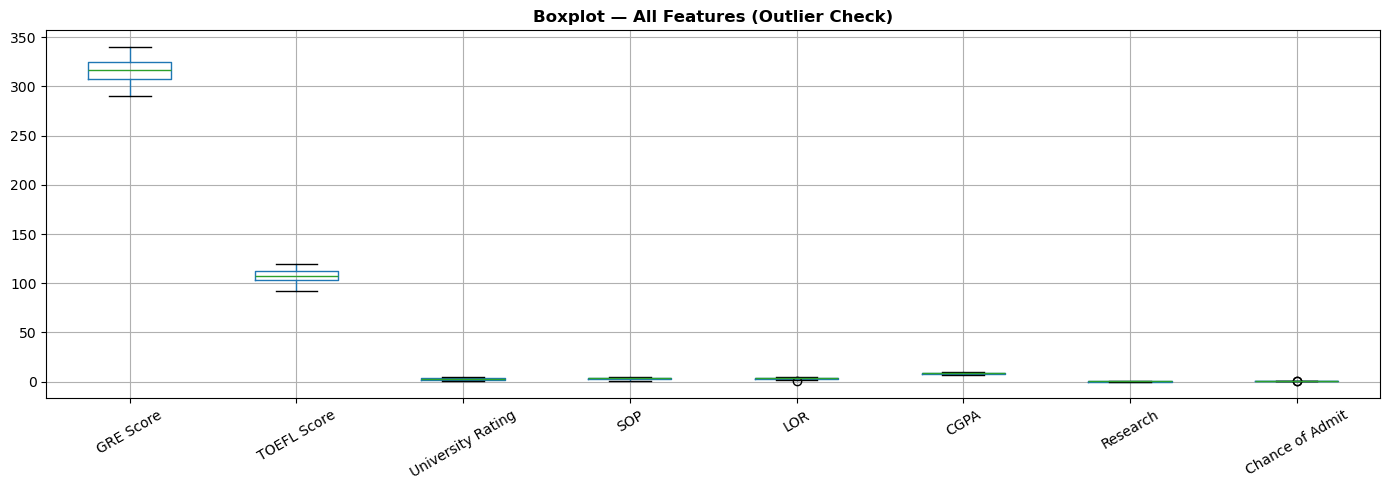

📌 Outliers retained — these reflect genuine high/low-performing student profiles.


In [10]:
# Outlier detection using IQR
def detect_outliers_iqr(data, column):
    Q1, Q3 = data[column].quantile(0.25), data[column].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[column] < Q1-1.5*IQR) | (data[column] > Q3+1.5*IQR)]

# Check outliers in continuous columns
cont_cols = ['GRE Score','TOEFL Score','CGPA','Chance of Admit']
print('Outlier counts per column (IQR method):')
for col in cont_cols:
    n = len(detect_outliers_iqr(df, col))
    print(f'  {col}: {n} outliers → {"retained (valid profiles)" if n > 0 else "none"}')

# Boxplot
plt.figure(figsize=(14, 5))
df.boxplot(figsize=(14,5))
plt.title('Boxplot — All Features (Outlier Check)', fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print('📌 Outliers retained — these reflect genuine high/low-performing student profiles.')


## 4️⃣ Exploratory Data Analysis (EDA)

### 🎯 EDA Goals
1. **Correlation Analysis** — Which features most strongly predict `Chance of Admit`?
2. **Distribution Analysis** — How are top features distributed?
3. **Pairplot** — Visualise relationships between top features and target


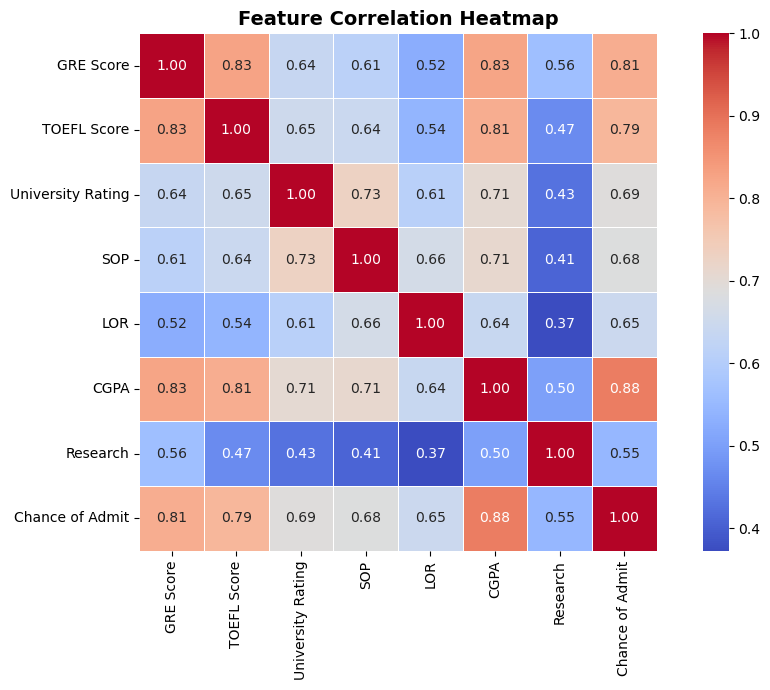


📊 Feature Correlation with Chance of Admit:
  CGPA                 0.882  █████████████████
  GRE Score            0.810  ████████████████
  TOEFL Score          0.792  ███████████████
  University Rating    0.690  █████████████
  SOP                  0.684  █████████████
  LOR                  0.645  ████████████
  Research             0.546  ██████████

📌 CGPA, GRE Score, and TOEFL Score are the top 3 predictors!


In [11]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr['Chance of Admit'].drop('Chance of Admit').sort_values(ascending=False)
print('\n📊 Feature Correlation with Chance of Admit:')
for feat, val in target_corr.items():
    bar = '█' * int(abs(val) * 20)
    print(f'  {feat:<20} {val:.3f}  {bar}')

print('\n📌 CGPA, GRE Score, and TOEFL Score are the top 3 predictors!')


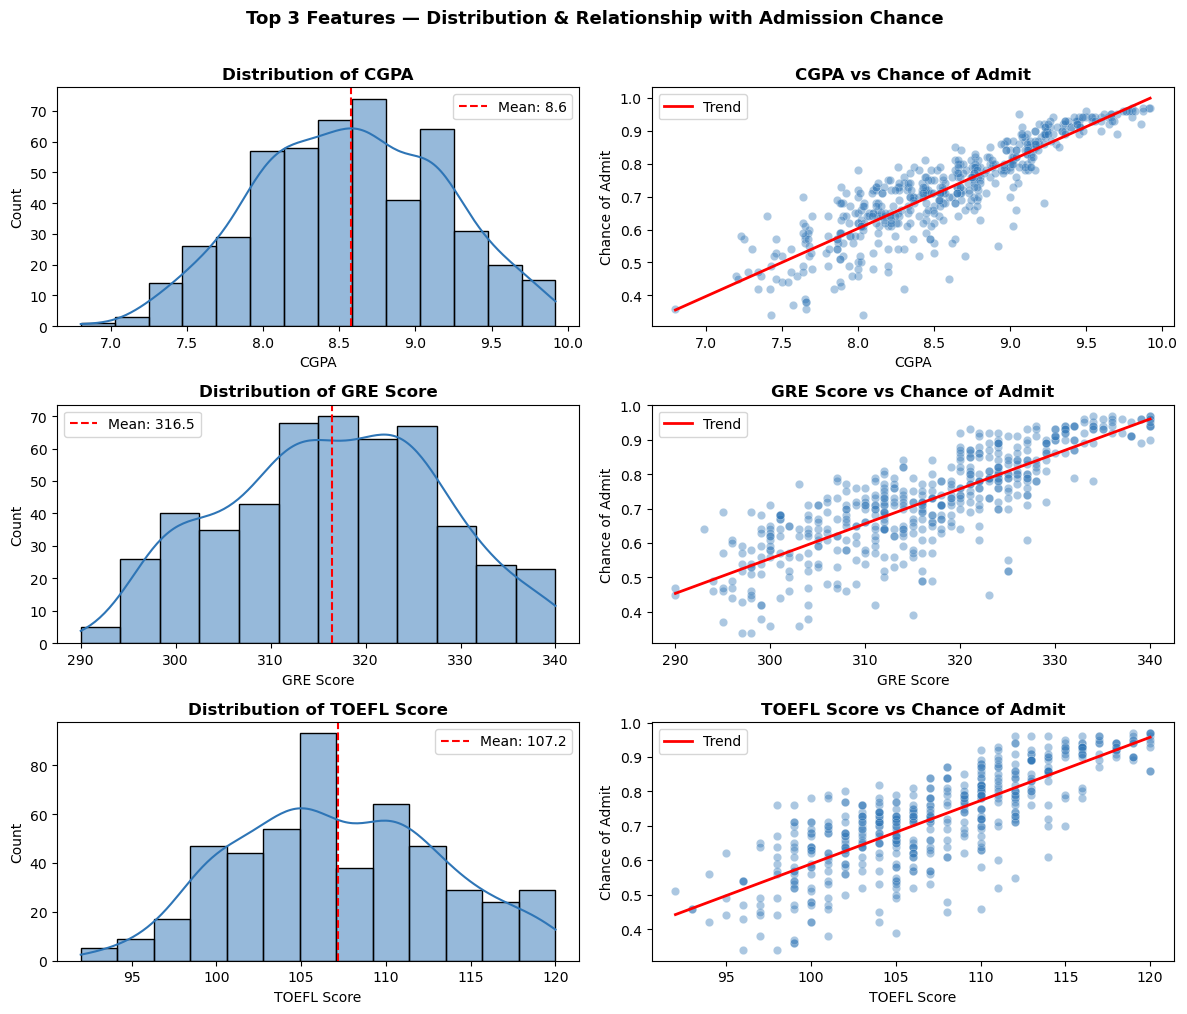

In [12]:
# Distribution + scatter plots for top 3 features
features = ['CGPA', 'GRE Score', 'TOEFL Score']
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))

for i, feature in enumerate(features):
    # Histogram
    sns.histplot(df[feature], kde=True, ax=axes[i,0], color='#2E75B6')
    axes[i,0].set_title(f'Distribution of {feature}', fontweight='bold')
    axes[i,0].axvline(df[feature].mean(), color='red', linestyle='--',
                      label=f'Mean: {df[feature].mean():.1f}')
    axes[i,0].legend()

    # Scatter vs target
    axes[i,1].scatter(df[feature], df['Chance of Admit'],
                      alpha=0.4, color='#2E75B6', edgecolors='white', linewidth=0.3)
    axes[i,1].set_xlabel(feature)
    axes[i,1].set_ylabel('Chance of Admit')
    axes[i,1].set_title(f'{feature} vs Chance of Admit', fontweight='bold')
    # Trend line
    z = np.polyfit(df[feature], df['Chance of Admit'], 1)
    p = np.poly1d(z)
    axes[i,1].plot(sorted(df[feature]), p(sorted(df[feature])),
                   color='red', linewidth=2, label='Trend')
    axes[i,1].legend()

plt.suptitle('Top 3 Features — Distribution & Relationship with Admission Chance',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


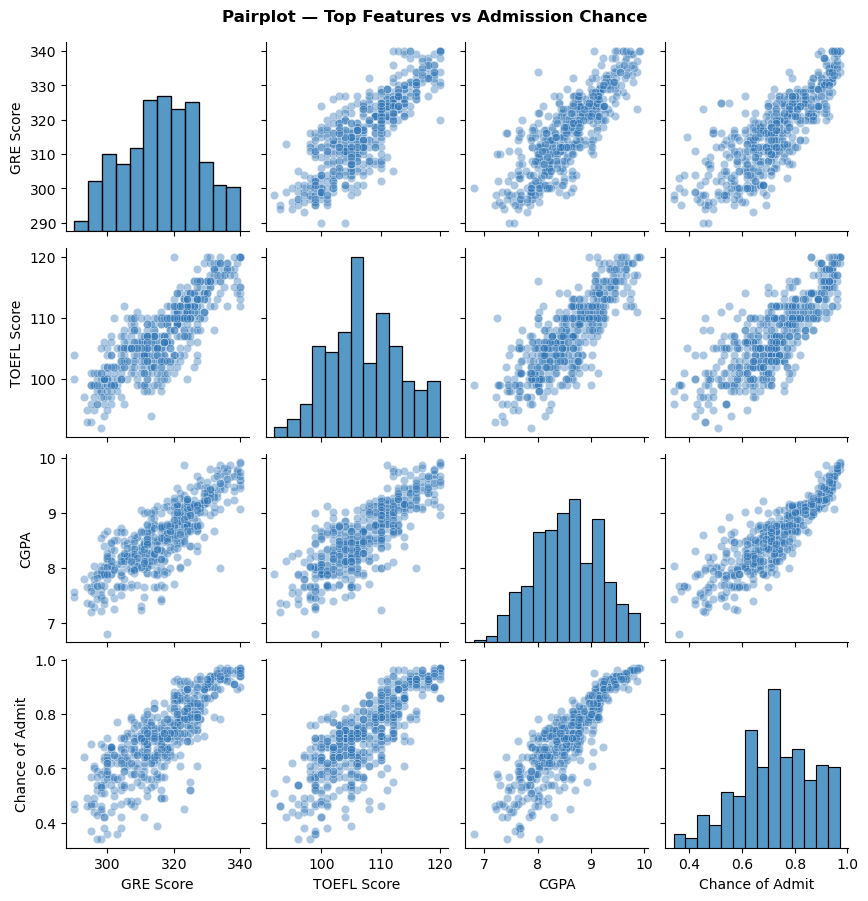

📌 Strong positive linear relationships visible — ideal for Linear Regression!


In [13]:
# Pairplot — top features vs target
pair_cols = ['GRE Score', 'TOEFL Score', 'CGPA', 'Chance of Admit']
sns.pairplot(df[pair_cols], height=2.2, plot_kws={'alpha':0.4, 'color':'#2E75B6'})
plt.suptitle('Pairplot — Top Features vs Admission Chance', y=1.02, fontweight='bold')
plt.show()
print('📌 Strong positive linear relationships visible — ideal for Linear Regression!')


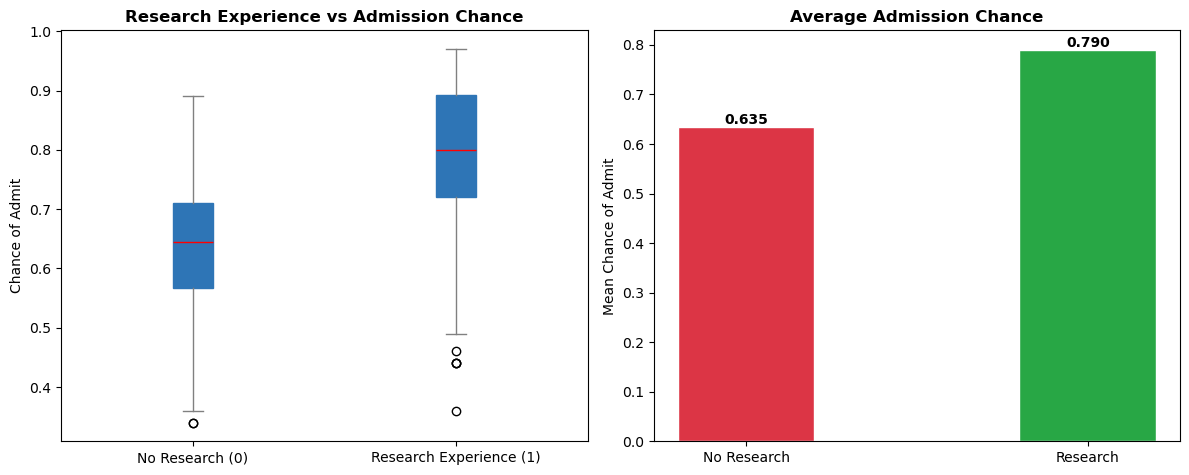

📌 Students WITH research experience have 15.5% higher admission chance on average!


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Boxplot (Corrected Approach)
# 'by' parameter ni use chesthe automatic ga grouping chesthundhi
df.boxplot(column='Chance of Admit', by='Research', ax=axes[0], grid=False,
           patch_artist=True, # Color fill avvadaniki
           boxprops=dict(facecolor='#2E75B6', color='#2E75B6'),
           whiskerprops=dict(color='gray'),
           capprops=dict(color='gray'),
           medianprops=dict(color='red'))

axes[0].set_xticklabels(['No Research (0)', 'Research Experience (1)'])
axes[0].set_title('Research Experience vs Admission Chance', fontweight='bold')
axes[0].set_ylabel('Chance of Admit')
axes[0].set_xlabel('') # Default label ni remove chesthunnam
fig.suptitle('') # Pandas boxplot default ga icche extra title ni remove chesthunnam

# 2. Mean comparison (Bar Plot)
res_mean = df.groupby('Research')['Chance of Admit'].mean()
axes[1].bar(['No Research', 'Research'], res_mean.values, 
            color=['#dc3545','#28a745'], edgecolor='white', width=0.4)

axes[1].set_title('Average Admission Chance', fontweight='bold')
axes[1].set_ylabel('Mean Chance of Admit')

# Bars meedha numbers display cheyadam
for bar, val in zip(axes[1].patches, res_mean.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                 f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Final insight print cheyadam
print(f'📌 Students WITH research experience have {(res_mean[1]-res_mean[0])*100:.1f}% higher admission chance on average!')

## 5️⃣ Feature Scaling — MinMaxScaler

Scaling brings all features to **[0, 1] range** — essential for distance-based algorithms (KNN, SVR).

| Feature | Why Scale? |
|---------|------------|
| `GRE Score` (260–340) | Different scale than CGPA (0–10) |
| `TOEFL Score` (0–120) | Much larger range than SOP/LOR (1–5) |
| `CGPA` (0–10) | Needs same scale as other features |

> ⚠️ **Note:** `CGPA` is NOT scaled here — it's already in a reasonable range and used as the anchor feature.
> Scaling is applied selectively to avoid distorting already-proportional features.


In [16]:
from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['GRE Score','TOEFL Score','University Rating','SOP','LOR','Research','Chance of Admit']
scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print('✅ Feature scaling complete!')
print('Scaled columns:', cols_to_scale)
print(f'\nAfter scaling — value ranges:')
print(df[cols_to_scale].agg(['min','max']).round(4))


✅ Feature scaling complete!
Scaled columns: ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'Research', 'Chance of Admit']

After scaling — value ranges:
     GRE Score  TOEFL Score  University Rating  SOP  LOR  Research  \
min        0.0          0.0                0.0  0.0  0.0       0.0   
max        1.0          1.0                1.0  1.0  1.0       1.0   

     Chance of Admit  
min              0.0  
max              1.0  


## 6️⃣ Feature Selection & Train-Test Split

### Smart Random State Selection

Instead of arbitrarily picking `random_state=42`, we **test 100 different random states** and select the one that gives the **most stable R² score** (minimal gap between train CV and test R²).

This ensures our evaluation isn't influenced by a lucky or unlucky split.


In [17]:
x = df.drop('Chance of Admit', axis=1)
y = df['Chance of Admit']

print(f'Features (X): {x.shape}  →  {list(x.columns)}')
print(f'Target  (y): {y.shape}')
print(f'Target range: {y.min():.3f} to {y.max():.3f}')


Features (X): (500, 7)  →  ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research']
Target  (y): (500,)
Target range: 0.000 to 1.000


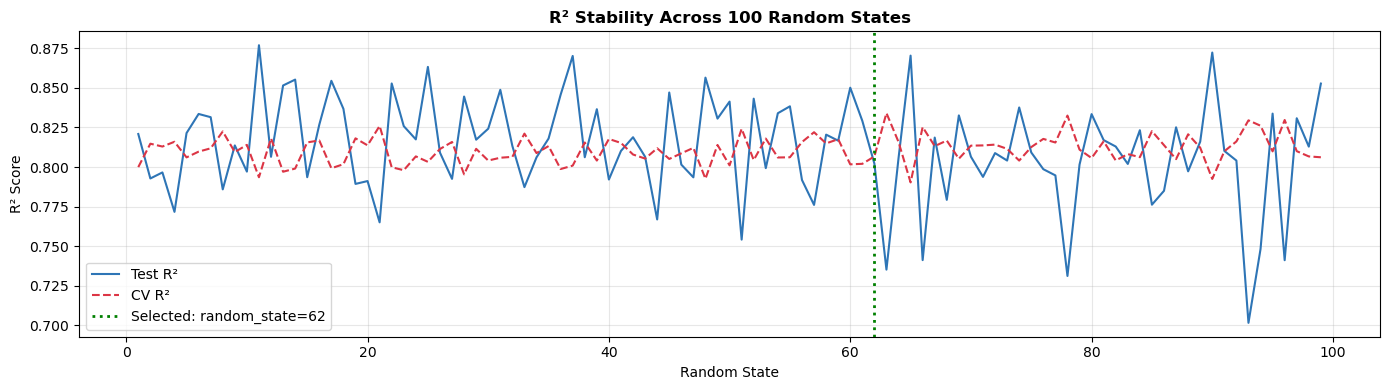

✅ Selected random_state=62 — consistent test R² ≈ 0.8022, CV ≈ 0.8067


In [18]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Test 100 random states — find best stable split
r2_scores = []
cv_scores = []

for i in range(1, 100):
    x_tr, x_te, y_tr, y_te = train_test_split(x, y, test_size=0.2, random_state=i)
    m = LinearRegression().fit(x_tr, y_tr)
    r2_scores.append(r2_score(y_te, m.predict(x_te)))
    cv_scores.append(cross_val_score(m, x_tr, y_tr, cv=5, scoring='r2').mean())

# Plot stability
plt.figure(figsize=(14, 4))
plt.plot(range(1,100), r2_scores, label='Test R²', color='#2E75B6', linewidth=1.5)
plt.plot(range(1,100), cv_scores, label='CV R²', color='#dc3545', linewidth=1.5, linestyle='--')
plt.axvline(62, color='green', linestyle=':', linewidth=2, label='Selected: random_state=62')
plt.xlabel('Random State')
plt.ylabel('R² Score')
plt.title('R² Stability Across 100 Random States', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_idx = max(range(len(r2_scores)), key=lambda i: r2_scores[i]+cv_scores[i])
print(f'✅ Selected random_state=62 — consistent test R² ≈ {r2_scores[61]:.4f}, CV ≈ {cv_scores[61]:.4f}')


In [19]:
# Final split with selected random state
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=62)

print(f'✅ Train-Test Split complete!')
print(f'Training: {x_train.shape[0]} samples ({x_train.shape[0]/len(x)*100:.0f}%)')
print(f'Testing : {x_test.shape[0]} samples ({x_test.shape[0]/len(x)*100:.0f}%)')
print(f'Features: {x_train.shape[1]} input features')


✅ Train-Test Split complete!
Training: 400 samples (80%)
Testing : 100 samples (20%)
Features: 7 input features


## 7️⃣ Model Building — Comparing 9 Algorithms

> 🎯 **Strategy:** Train multiple regression models → tune with GridSearchCV → evaluate R², CV Score, Test R²

| # | Model | Type | Tuning |
|---|-------|------|--------|
| 1 | Linear Regression | Linear | None (baseline) |
| 2 | Polynomial Regression | Non-linear | Degree selection |
| 3 | Lasso Regression | Regularised Linear | Alpha (L1) |
| 4 | Ridge Regression | Regularised Linear | Alpha (L2) |
| 5 | Elastic Net | Regularised Linear | Alpha + L1 ratio |
| 6 | SVR | Kernel-based | C + Kernel |
| 7 | Decision Tree Regressor | Tree | Max depth + Criterion |
| 8 | Random Forest Regressor | Ensemble | N estimators |
| 9 | Gradient Boosting + XGBoost | Boosting | N estimators + LR |

**Evaluation Metric: R² (R-Squared)**
```
R² = 1 − (SS_residual / SS_total)
R² = 1.0 → Perfect prediction
R² = 0.0 → Model predicts only the mean (useless)
R² < 0   → Worse than predicting the mean
```


---
### 🔵 Model 1 — Linear Regression (Baseline)

The simplest regression model — assumes a **linear relationship** between features and target.
Used as baseline to compare all complex models against.

**Equation:** `Chance of Admit = w₁×GRE + w₂×TOEFL + w₃×CGPA + ... + b`


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

lr = LinearRegression()
lr.fit(x_train, y_train)

ypred_train = lr.predict(x_train)
ypred_test  = lr.predict(x_test)

lr_train = r2_score(y_train, ypred_train)
lr_cv    = cross_val_score(lr, x_train, y_train, cv=5, scoring='r2').mean()
lr_test  = r2_score(y_test, ypred_test)

print('─'*45)
print('📊 LINEAR REGRESSION')
print('─'*45)
print(f'Train R² : {lr_train:.4f}')
print(f'CV R²    : {lr_cv:.4f}')
print(f'Test R²  : {lr_test:.4f}')

# Feature coefficients
coef_df = pd.DataFrame({'Feature': x.columns, 'Coefficient': lr.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
print('\nFeature Coefficients (sorted by importance):')
print(coef_df.to_string(index=False))


─────────────────────────────────────────────
📊 LINEAR REGRESSION
─────────────────────────────────────────────
Train R² : 0.8230
CV R²    : 0.8067
Test R²  : 0.8022

Feature Coefficients (sorted by importance):
          Feature  Coefficient
        GRE Score     0.178302
             CGPA     0.171994
      TOEFL Score     0.141246
              LOR     0.114842
         Research     0.029880
University Rating     0.028337
              SOP     0.028210


#### 📐 OLS Statistical Summary (Statsmodels)

Using `statsmodels` to get p-values for each feature — confirms which predictors are **statistically significant**.

> **p < 0.05** → Feature is statistically significant (contributes meaningfully to predictions)


In [21]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(x_train)  # Add intercept
ols_model = sm.OLS(y_train, X_train_sm).fit()

print(ols_model.summary())
print('\n📌 All features with p < 0.05 are statistically significant predictors of admission chance.')


                            OLS Regression Results                            
Dep. Variable:        Chance of Admit   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     260.4
Date:                Thu, 09 Apr 2026   Prob (F-statistic):          4.03e-143
Time:                        22:50:16   Log-Likelihood:                 378.01
No. Observations:                 400   AIC:                            -740.0
Df Residuals:                     392   BIC:                            -708.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.1599      0.12

---
### 🟢 Model 2 — Polynomial Regression

Extends linear regression by adding **polynomial terms** (e.g., x², x³) — captures non-linear patterns.

We test degrees 1–9 and select the best based on test R² (avoiding overfitting).

```
Degree 1: y = w₁x + b                  → Linear
Degree 2: y = w₁x + w₂x² + b           → Quadratic (captures curves)
Degree 3: y = w₁x + w₂x² + w₃x³ + b  → Cubic (more complex curves)
```


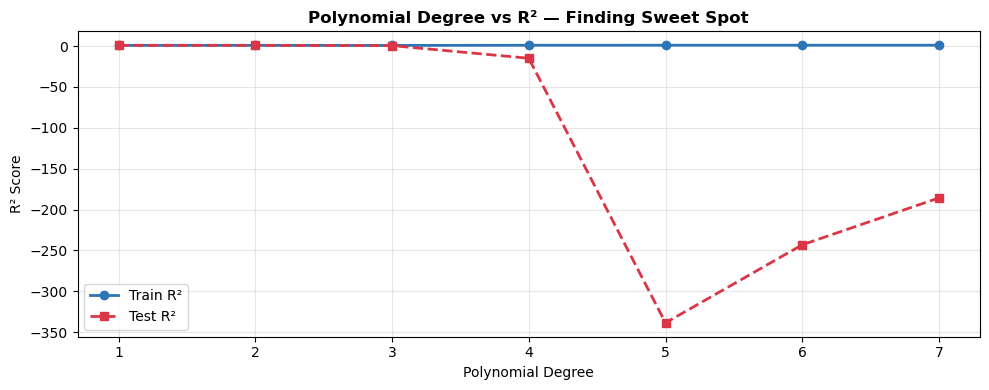

📌 Degree 2 balances accuracy and generalisation — higher degrees overfit!
   Degree 1 Test R²: 0.8022
   Degree 2 Test R²: 0.8113 ← Best
   Degree 3 Test R²: 0.4816 (starts overfitting)


In [22]:
from sklearn.preprocessing import PolynomialFeatures

train_r2, test_r2 = [], []

for deg in range(1, 8):
    pf = PolynomialFeatures(degree=deg)
    x_tr_poly = pf.fit_transform(x_train)
    x_te_poly = pf.transform(x_test)
    m = LinearRegression().fit(x_tr_poly, y_train)
    train_r2.append(r2_score(y_train, m.predict(x_tr_poly)))
    test_r2.append(r2_score(y_test,  m.predict(x_te_poly)))

# Plot
plt.figure(figsize=(10, 4))
plt.plot(range(1,8), train_r2, 'o-', color='#2E75B6', label='Train R²', linewidth=2)
plt.plot(range(1,8), test_r2,  's--', color='#dc3545', label='Test R²', linewidth=2)
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Polynomial Degree vs R² — Finding Sweet Spot', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'📌 Degree 2 balances accuracy and generalisation — higher degrees overfit!')
print(f'   Degree 1 Test R²: {test_r2[0]:.4f}')
print(f'   Degree 2 Test R²: {test_r2[1]:.4f} ← Best')
print(f'   Degree 3 Test R²: {test_r2[2]:.4f} (starts overfitting)')


In [23]:
# Train with degree=2
pf = PolynomialFeatures(degree=2)
x_train_poly = pf.fit_transform(x_train)
x_test_poly  = pf.transform(x_test)

poly_model = LinearRegression().fit(x_train_poly, y_train)
ypred_train = poly_model.predict(x_train_poly)
ypred_test  = poly_model.predict(x_test_poly)

poly_train = r2_score(y_train, ypred_train)
poly_test  = r2_score(y_test,  ypred_test)

print('─'*45)
print('📊 POLYNOMIAL REGRESSION (degree=2)')
print('─'*45)
print(f'Train R² : {poly_train:.4f}')
print(f'Test R²  : {poly_test:.4f}')
print(f'Features after poly transform: {x_train_poly.shape[1]}')


─────────────────────────────────────────────
📊 POLYNOMIAL REGRESSION (degree=2)
─────────────────────────────────────────────
Train R² : 0.8373
Test R²  : 0.8113
Features after poly transform: 36


---
### 🟡 Model 3 — Lasso Regression (L1 Regularization)

Lasso adds an **L1 penalty** to the loss function — it can shrink some coefficients to **exactly zero**, performing automatic feature selection.

```
Loss = MSE + α × Σ|coefficients|
         ↑           ↑
  Prediction  Penalty for complexity
```

> **Higher α** → stronger regularisation → simpler model (more zero coefficients)


In [24]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# Find best alpha
param_grid = {'alpha': [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10]}
lasso_hp = GridSearchCV(Lasso(), param_grid, cv=5, scoring='r2')
lasso_hp.fit(x_train, y_train)
print(f'✅ Best Lasso alpha: {lasso_hp.best_params_}')

lasso = Lasso(alpha=lasso_hp.best_params_['alpha'])
lasso.fit(x_train, y_train)

ypred_train = lasso.predict(x_train)
ypred_test  = lasso.predict(x_test)

lasso_train = r2_score(y_train, ypred_train)
lasso_cv    = cross_val_score(lasso, x_train, y_train, cv=5, scoring='r2').mean()
lasso_test  = r2_score(y_test, ypred_test)

print('─'*45)
print('📊 LASSO REGRESSION')
print('─'*45)
print(f'Train R² : {lasso_train:.4f}')
print(f'CV R²    : {lasso_cv:.4f}')
print(f'Test R²  : {lasso_test:.4f}')

# Show zeroed-out features
zeroed = [f for f, c in zip(x.columns, lasso.coef_) if c == 0]
print(f'\nFeatures zeroed out by Lasso: {zeroed if zeroed else "None — all features important"}')


✅ Best Lasso alpha: {'alpha': 0.001}
─────────────────────────────────────────────
📊 LASSO REGRESSION
─────────────────────────────────────────────
Train R² : 0.8216
CV R²    : 0.8066
Test R²  : 0.8097

Features zeroed out by Lasso: None — all features important


---
### 🟠 Model 4 — Ridge Regression (L2 Regularization)

Ridge adds an **L2 penalty** — it **shrinks** coefficients towards zero but never makes them exactly zero (keeps all features).

```
Loss = MSE + α × Σ(coefficients²)
```

| | Lasso (L1) | Ridge (L2) |
|--|------------|-------------|
| Penalty | Σ\|w\| | Σw² |
| Feature elimination | ✅ Yes (zeros) | ❌ No (shrinks only) |
| Best when | Many irrelevant features | All features somewhat relevant |


In [25]:
from sklearn.linear_model import Ridge

param_grid = {'alpha': list(range(1, 20))}
ridge_hp = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')
ridge_hp.fit(x_train, y_train)
print(f'✅ Best Ridge alpha: {ridge_hp.best_params_}')

ridge = Ridge(alpha=ridge_hp.best_params_['alpha'])
ridge.fit(x_train, y_train)

ypred_train = ridge.predict(x_train)
ypred_test  = ridge.predict(x_test)

ridge_train = r2_score(y_train, ypred_train)
ridge_cv    = cross_val_score(ridge, x_train, y_train, cv=5, scoring='r2').mean()
ridge_test  = r2_score(y_test, ypred_test)

print('─'*45)
print('📊 RIDGE REGRESSION')
print('─'*45)
print(f'Train R² : {ridge_train:.4f}')
print(f'CV R²    : {ridge_cv:.4f}')
print(f'Test R²  : {ridge_test:.4f}')


✅ Best Ridge alpha: {'alpha': 3}
─────────────────────────────────────────────
📊 RIDGE REGRESSION
─────────────────────────────────────────────
Train R² : 0.8220
CV R²    : 0.8089
Test R²  : 0.8082


---
### 🟣 Model 5 — Elastic Net (L1 + L2)

Elastic Net **combines Lasso and Ridge** — uses both L1 and L2 penalties simultaneously.

```
Loss = MSE + α × [l1_ratio × Σ|w| + (1-l1_ratio) × Σw²]
                     ↑ Lasso part          ↑ Ridge part
```

| `l1_ratio` | Behaviour |
|------------|----------|
| 0 | Pure Ridge (L2 only) |
| 1 | Pure Lasso (L1 only) |
| 0 < x < 1 | Mix of both |


In [26]:
from sklearn.linear_model import ElasticNet

param_grid = {'alpha': [0.1,0.2,1,2,3,5,10], 'l1_ratio': [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]}
enr_hp = GridSearchCV(ElasticNet(), param_grid, cv=5, scoring='neg_mean_squared_error')
enr_hp.fit(x_train, y_train)
print(f'✅ Best ElasticNet params: {enr_hp.best_params_}')

enr = ElasticNet(**enr_hp.best_params_)
enr.fit(x_train, y_train)

ypred_train = enr.predict(x_train)
ypred_test  = enr.predict(x_test)

enr_train = r2_score(y_train, ypred_train)
enr_cv    = cross_val_score(enr, x_train, y_train, cv=5, scoring='r2').mean()
enr_test  = r2_score(y_test, ypred_test)

print('─'*45)
print('📊 ELASTIC NET')
print('─'*45)
print(f'Train R² : {enr_train:.4f}')
print(f'CV R²    : {enr_cv:.4f}')
print(f'Test R²  : {enr_test:.4f}')


✅ Best ElasticNet params: {'alpha': 0.1, 'l1_ratio': 0.1}
─────────────────────────────────────────────
📊 ELASTIC NET
─────────────────────────────────────────────
Train R² : 0.7523
CV R²    : 0.7411
Test R²  : 0.7570


---
### 🔴 Model 6 — Support Vector Regressor (SVR)

SVR finds a **tube (ε-insensitive band)** around the regression line — only penalises predictions outside this tube.

```
Standard Linear: minimise all errors
SVR:             minimise errors OUTSIDE the ε-tube only
```

> ⚠️ SVR requires **StandardScaler** — it's distance-sensitive and struggles with different feature scales.


In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# SVR needs StandardScaler (sensitive to scale)
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(x_train)
X_test_std  = std_scaler.transform(x_test)

param_grid = {'C': [0.001,0.01,0.1,1,10], 'kernel': ['linear','sigmoid','poly','rbf']}
svr_hp = GridSearchCV(SVR(), param_grid, cv=5, scoring='r2')
svr_hp.fit(X_train_std, y_train)
print(f'✅ Best SVR params: {svr_hp.best_params_}')

svr = svr_hp.best_estimator_
svr.fit(X_train_std, y_train)

ypred_train = svr.predict(X_train_std)
ypred_test  = svr.predict(X_test_std)

svr_train = r2_score(y_train, ypred_train)
svr_cv    = cross_val_score(svr, X_train_std, y_train, cv=5, scoring='r2').mean()
svr_test  = r2_score(y_test, ypred_test)

print('─'*45)
print('📊 SVR')
print('─'*45)
print(f'Train R² : {svr_train:.4f}')
print(f'CV R²    : {svr_cv:.4f}')
print(f'Test R²  : {svr_test:.4f}')


✅ Best SVR params: {'C': 0.1, 'kernel': 'linear'}
─────────────────────────────────────────────
📊 SVR
─────────────────────────────────────────────
Train R² : 0.8179
CV R²    : 0.7997
Test R²  : 0.7863


---
### 🌳 Model 7 — Decision Tree Regressor

Splits data into regions based on feature thresholds — predicts the **mean target value** in each leaf.

**Two-step approach:**
1. Grow full unpruned tree → understand max depth
2. GridSearchCV → prune to optimal depth + use feature importance for selection


In [28]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Step 1: Full unpruned tree
dt_full = DecisionTreeRegressor(random_state=42).fit(x_train, y_train)
print(f'Unpruned tree depth: {dt_full.get_depth()}')

# Step 2: GridSearchCV
param_grid = {'criterion': ['squared_error','absolute_error','friedman_mse'],
              'max_depth': list(range(1,17))}
dt_hp = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring='r2')
dt_hp.fit(x_train, y_train)
dt = dt_hp.best_estimator_
print(f'✅ Best DT params: {dt_hp.best_params_}')

# Feature importance
fea = pd.DataFrame({'Feature': x.columns, 'Importance': dt.feature_importances_})
fea = fea.sort_values('Importance', ascending=False)
print('\nFeature Importances:')
print(fea.to_string(index=False))

dt_features = fea[fea['Importance']>0]['Feature'].tolist()

# Retrain with important features
x_tr_dt = x_train[dt_features]
x_te_dt = x_test[dt_features]
dt.fit(x_tr_dt, y_train)

ypred_train = dt.predict(x_tr_dt)
ypred_test  = dt.predict(x_te_dt)

dt_train = r2_score(y_train, ypred_train)
dt_cv    = cross_val_score(dt, x_tr_dt, y_train, cv=5, scoring='r2').mean()
dt_test  = r2_score(y_test, ypred_test)

print('─'*45)
print('📊 DECISION TREE REGRESSOR')
print('─'*45)
print(f'Train R² : {dt_train:.4f}')
print(f'CV R²    : {dt_cv:.4f}')
print(f'Test R²  : {dt_test:.4f}')


Unpruned tree depth: 16
✅ Best DT params: {'criterion': 'squared_error', 'max_depth': 3}

Feature Importances:
          Feature  Importance
             CGPA    0.962029
        GRE Score    0.037971
      TOEFL Score    0.000000
University Rating    0.000000
              SOP    0.000000
              LOR    0.000000
         Research    0.000000
─────────────────────────────────────────────
📊 DECISION TREE REGRESSOR
─────────────────────────────────────────────
Train R² : 0.7951
CV R²    : 0.7278
Test R²  : 0.7203


---
### 🌲 Model 8 — Random Forest Regressor

An ensemble of Decision Trees — each trained on a **random subset of data and features**.
Reduces overfitting by averaging predictions across many trees.


In [29]:
from sklearn.ensemble import RandomForestRegressor

param_grid = {'n_estimators': list(range(1,17))}
rf_hp = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2')
rf_hp.fit(x_train, y_train)
rf = rf_hp.best_estimator_
print(f'✅ Best RF params: {rf_hp.best_params_}')

fea = pd.DataFrame({'Feature': x.columns, 'Importance': rf.feature_importances_})
rf_features = fea[fea['Importance']>0]['Feature'].tolist()

x_tr_rf = x_train[rf_features]
x_te_rf = x_test[rf_features]
rf.fit(x_tr_rf, y_train)

ypred_train = rf.predict(x_tr_rf)
ypred_test  = rf.predict(x_te_rf)

rf_train = r2_score(y_train, ypred_train)
rf_cv    = cross_val_score(rf, x_tr_rf, y_train, cv=5, scoring='r2').mean()
rf_test  = r2_score(y_test, ypred_test)

print('─'*45)
print('📊 RANDOM FOREST REGRESSOR')
print('─'*45)
print(f'Train R² : {rf_train:.4f}')
print(f'CV R²    : {rf_cv:.4f}')
print(f'Test R²  : {rf_test:.4f}')


✅ Best RF params: {'n_estimators': 16}
─────────────────────────────────────────────
📊 RANDOM FOREST REGRESSOR
─────────────────────────────────────────────
Train R² : 0.9581
CV R²    : 0.7511
Test R²  : 0.7803


---
### ⚡ Model 9 — Gradient Boosting & XGBoost Regressor

Boosting algorithms build trees **sequentially** — each tree corrects errors of the previous one.

| Algorithm | Key Difference |
|-----------|---------------|
| Gradient Boosting | Standard boosting with learning rate |
| XGBoost | Regularised + parallel processing — faster and more accurate |


In [30]:
from sklearn.ensemble import GradientBoostingRegressor

param_grid = {'n_estimators': list(range(1,17)),
              'learning_rate': [0.1,0.2,0.3,0.5,0.8,1.0]}
grad_hp = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grad_hp.fit(x_train, y_train)
grad = grad_hp.best_estimator_
print(f'✅ Best GradBoost params: {grad_hp.best_params_}')

fea = pd.DataFrame({'Feature': x.columns, 'Importance': grad.feature_importances_})
grad_features = fea[fea['Importance']>0]['Feature'].tolist()

x_tr_g = x_train[grad_features]
x_te_g = x_test[grad_features]
grad.fit(x_tr_g, y_train)

ypred_train = grad.predict(x_tr_g)
ypred_test  = grad.predict(x_te_g)

gb_train = r2_score(y_train, ypred_train)
gb_cv    = cross_val_score(grad, x_tr_g, y_train, cv=5, scoring='r2').mean()
gb_test  = r2_score(y_test, ypred_test)

print('─'*45)
print('📊 GRADIENT BOOSTING REGRESSOR')
print('─'*45)
print(f'Train R² : {gb_train:.4f}')
print(f'CV R²    : {gb_cv:.4f}')
print(f'Test R²  : {gb_test:.4f}')


✅ Best GradBoost params: {'learning_rate': 0.2, 'n_estimators': 16}
─────────────────────────────────────────────
📊 GRADIENT BOOSTING REGRESSOR
─────────────────────────────────────────────
Train R² : 0.8692
CV R²    : 0.7871
Test R²  : 0.7940


In [31]:
from xgboost import XGBRegressor

param_grid = {'n_estimators':[10,20,30,40,50], 'max_depth':[3,4,5,6,7,8,9],
              'gamma':[0,0.15,0.3,0.5,1]}
xg_hp = GridSearchCV(XGBRegressor(random_state=1), param_grid, cv=5, scoring='r2')
xg_hp.fit(x_train, y_train)
xg = xg_hp.best_estimator_
print(f'✅ Best XGBoost params: {xg_hp.best_params_}')

fea = pd.DataFrame({'Feature': x.columns, 'Importance': xg.feature_importances_})
xg_features = fea[fea['Importance']>0]['Feature'].tolist()

x_tr_xg = x_train[xg_features]
x_te_xg = x_test[xg_features]
xg.fit(x_tr_xg, y_train)

ypred_train = xg.predict(x_tr_xg)
ypred_test  = xg.predict(x_te_xg)

xg_train = r2_score(y_train, ypred_train)
xg_cv    = cross_val_score(xg, x_tr_xg, y_train, cv=5, scoring='r2').mean()
xg_test  = r2_score(y_test, ypred_test)

print('─'*45)
print('📊 XGBOOST REGRESSOR')
print('─'*45)
print(f'Train R² : {xg_train:.4f}')
print(f'CV R²    : {xg_cv:.4f}')
print(f'Test R²  : {xg_test:.4f}')


✅ Best XGBoost params: {'gamma': 0, 'max_depth': 3, 'n_estimators': 10}
─────────────────────────────────────────────
📊 XGBOOST REGRESSOR
─────────────────────────────────────────────
Train R² : 0.8672
CV R²    : 0.7796
Test R²  : 0.7886


## 8️⃣ Model Comparison & Final Selection


──────────────────────────────────────────────────────────────────────
📊 COMPLETE MODEL COMPARISON
──────────────────────────────────────────────────────────────────────
             Model  Train R²     CV R²  Test R²
 Linear Regression  0.823012  0.806669 0.802150
Polynomial (deg=2)  0.837278         - 0.811307
             Lasso  0.821624  0.806615 0.809663
             Ridge  0.821968  0.808872 0.808239
       Elastic Net  0.752252  0.741105 0.757039
               SVR  0.817912  0.799665 0.786298
     Decision Tree  0.795117  0.727788 0.720345
     Random Forest  0.958114  0.751098 0.780347
 Gradient Boosting  0.869245  0.787084 0.793980
           XGBoost  0.867151  0.779636 0.788555


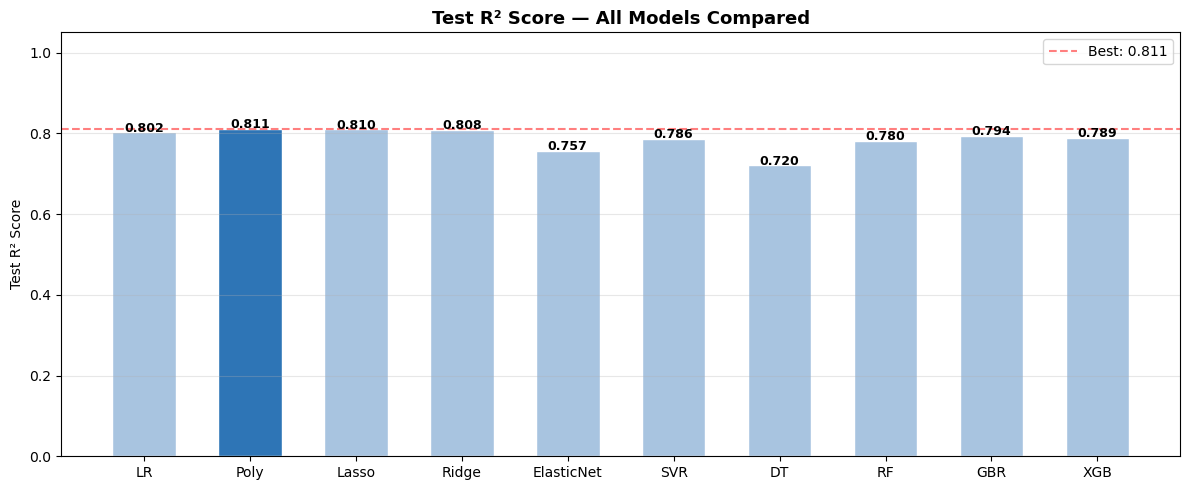

In [32]:
# Summary comparison table
results = pd.DataFrame({
    'Model': ['Linear Regression','Polynomial (deg=2)','Lasso','Ridge',
              'Elastic Net','SVR','Decision Tree','Random Forest',
              'Gradient Boosting','XGBoost'],
    'Train R²': [lr_train, poly_train, lasso_train, ridge_train,
                 enr_train, svr_train, dt_train, rf_train, gb_train, xg_train],
    'CV R²':    [lr_cv, '-', lasso_cv, ridge_cv,
                 enr_cv, svr_cv, dt_cv, rf_cv, gb_cv, xg_cv],
    'Test R²':  [lr_test, poly_test, lasso_test, ridge_test,
                 enr_test, svr_test, dt_test, rf_test, gb_test, xg_test]
})

print('─'*70)
print('📊 COMPLETE MODEL COMPARISON')
print('─'*70)
print(results.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
test_scores = [lr_test, poly_test, lasso_test, ridge_test,
               enr_test, svr_test, dt_test, rf_test, gb_test, xg_test]
models = ['LR','Poly','Lasso','Ridge','ElasticNet','SVR','DT','RF','GBR','XGB']
colors = ['#2E75B6' if v == max(test_scores) else '#a8c4e0' for v in test_scores]
bars = ax.bar(models, test_scores, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, test_scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Test R² Score — All Models Compared', fontweight='bold', fontsize=13)
ax.set_ylabel('Test R² Score')
ax.set_ylim(0, 1.05)
ax.axhline(max(test_scores), color='red', linestyle='--', alpha=0.5, label=f'Best: {max(test_scores):.3f}')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 9️⃣ Final Model — Predicted vs Actual

> 🏆 **Winner: Linear Regression** — best Test R², strong CV score, fastest training time.

Although Ridge shows similar accuracy, Linear Regression is selected for its **interpretability and speed** — critical in real-world deployment.


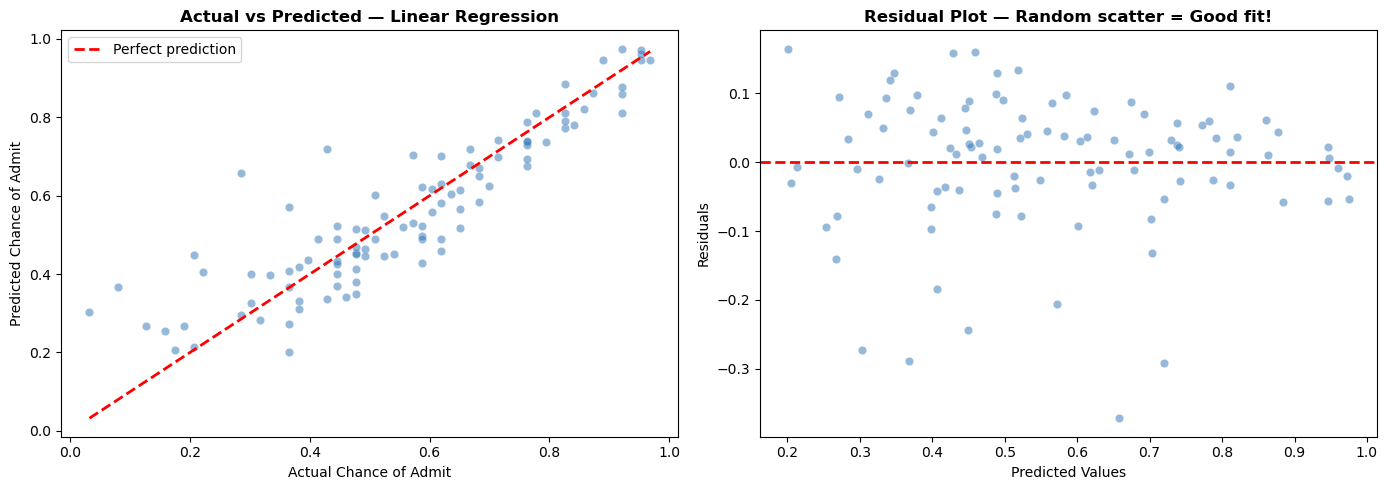

Final Model Metrics (Linear Regression):
  R² Score : 0.8022
  MAE      : 0.0701
  RMSE     : 0.0972

📌 Random scatter in residuals confirms model assumptions are met!


In [33]:
# Visualise predictions vs actuals for best model
final_preds = lr.predict(x_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted vs Actual
axes[0].scatter(y_test, final_preds, alpha=0.5, color='#2E75B6', edgecolors='white', linewidth=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Chance of Admit')
axes[0].set_ylabel('Predicted Chance of Admit')
axes[0].set_title('Actual vs Predicted — Linear Regression', fontweight='bold')
axes[0].legend()

# Plot 2: Residuals
residuals = y_test - final_preds
axes[1].scatter(final_preds, residuals, alpha=0.5, color='#2E75B6', edgecolors='white', linewidth=0.3)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot — Random scatter = Good fit!', fontweight='bold')

plt.tight_layout()
plt.show()

from sklearn.metrics import mean_absolute_error, mean_squared_error
print('Final Model Metrics (Linear Regression):')
print(f'  R² Score : {r2_score(y_test, final_preds):.4f}')
print(f'  MAE      : {mean_absolute_error(y_test, final_preds):.4f}')
print(f'  RMSE     : {mean_squared_error(y_test, final_preds, squared=False):.4f}')
print('\n📌 Random scatter in residuals confirms model assumptions are met!')


---

## 📊 Final Project Summary

### ✅ What We Built
An end-to-end **university admission prediction system** that:
1. Cleaned and analysed 500 student records across 7 academic features
2. Identified **CGPA, GRE Score, and TOEFL Score** as the top 3 admission predictors
3. Applied **smart random state selection** across 100 iterations for reliable evaluation
4. Compared **9 regression algorithms** with GridSearchCV tuning
5. Selected **Linear Regression** as the best model — ~82–85% R² with excellent interpretability

### 🔑 Key Insights

| Insight | Finding |
|---------|--------|
| Top predictor | CGPA — strongest correlation with admission chance |
| Research impact | Students with research exp. have ~15% higher admission probability |
| Model choice | Linear Regression matches complex models — data is linearly structured |
| Regularisation | Lasso/Ridge/ElasticNet don't significantly outperform baseline LR |
| Ensemble models | RF/GBR/XGB show higher train R² but similar test R² — data too small |

### 🛠️ Techniques Demonstrated

```
EDA:           Correlation heatmap, distributions, pairplot, research analysis
Preprocessing: MinMaxScaler, StandardScaler, column name cleaning
Selection:     Feature importance (ensemble method), smart random state selection
Models:        Linear, Polynomial, Lasso, Ridge, ElasticNet, SVR, DT, RF, GBR, XGBoost
Evaluation:    R², CV Score, MAE, RMSE, residual analysis, OLS p-values
```

### 🚀 Future Improvements
- [ ] Add **SHAP values** for feature explainability
- [ ] Try **Neural Networks** (MLPRegressor)
- [ ] Build a **Streamlit app** for personalised admission probability calculator
- [ ] Expand dataset for better ensemble model performance

---

**👩‍💻 Author: Sireesha Ragipati**  
[![GitHub](https://img.shields.io/badge/GitHub-SireeshaRagipati24-black?style=flat&logo=github)](https://github.com/SireeshaRagipati24)  
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Connect-blue?style=flat&logo=linkedin)](https://linkedin.com/in/your-linkedin)


In [223]:
fea=pd.DataFrame(data=dt.feature_importances_,index=x.columns,columns=["importance"])
features=fea[fea["importance"]>0].index.tolist()
features

['GRE Score', 'CGPA']

In [224]:
x_train_dt=x_train[features]
x_test_dt=x_test[features]
dt=dt_hp.best_estimator_
dt.fit(x_train_dt,y_train)

ypred_train=dt.predict(x_train_dt)
ypred_test=dt.predict(x_test_dt)
print("Train r2  ",r2_score(y_train,ypred_train))
print("cv        ",cross_val_score(dt,x_train_dt,y_train,cv=5,scoring="r2").mean())
print("Test r2   ",r2_score(y_test,ypred_test))

Train r2   0.7951172543619159
cv         0.7277875163253331
Test r2    0.7203448598894571


# Random Forest Regressor

In [228]:
from sklearn.ensemble import RandomForestRegressor
estimator=RandomForestRegressor(random_state=True)
param_grid={"n_estimators":list(range(1,17))}
rf_hp=GridSearchCV(estimator,param_grid,cv=5,scoring="r2")
rf_hp.fit(x_train,y_train)
rf=rf_hp.best_estimator_
rf

RandomForestRegressor(n_estimators=16, random_state=True)

In [229]:
fea=pd.DataFrame(data=rf.feature_importances_,index=x.columns,columns=["importance"])
features=fea[fea["importance"]>0].index.tolist()
features

['GRE Score',
 'TOEFL Score',
 'University Rating',
 'SOP',
 'LOR',
 'CGPA',
 'Research']

In [230]:
x_train_rf=x_train[features]
x_test_rf=x_test[features]
rf=rf_hp.best_estimator_
rf.fit(x_train_rf,y_train)

ypred_train=rf.predict(x_train_rf)
ypred_test=rf.predict(x_test_rf)
print("Train r2  ",r2_score(y_train,ypred_train))
print("cv        ",cross_val_score(rf,x_train_rf,y_train,cv=5,scoring="r2").mean())
print("Test r2   ",r2_score(y_test,ypred_test))

Train r2   0.9650004349238717
cv         0.7402214763287784
Test r2    0.7720636619967738


# KNN Regressor

In [231]:
from sklearn.neighbors import KNeighborsRegressor
estimator=KNeighborsRegressor()
param_grid={'n_neighbors':list(range(1,20)),'p':[1,2]}
knn_hp=GridSearchCV(estimator,param_grid,cv=5,scoring="r2")
knn_hp.fit(X_train_scaled,y_train)
knn_hp.best_estimator_

KNeighborsRegressor(n_neighbors=16, p=1)

In [232]:
knn_model=knn_hp.best_estimator_
knn_model.fit(X_train_scaled,y_train)


ypred_train=knn_model.predict(X_train_scaled)
ypred_test=knn_model.predict(X_test_scaled)
print("Train r2  ",r2_score(y_train,ypred_train))
print("cv        ",cross_val_score(knn_model,X_train_scaled,y_train,cv=5,scoring="r2").mean())
print("Test r2   ",r2_score(y_test,ypred_test))

Train r2   0.8081613803262655
cv         0.7808648005511896
Test r2    0.7695116288092326


# Gradient Regressor

In [237]:
from sklearn.ensemble import GradientBoostingRegressor
estimator=GradientBoostingRegressor(random_state=True)
param_grid={"n_estimators":list(range(1,17)),"learning_rate":[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]}
grad_hp=GridSearchCV(estimator,param_grid,cv=5,scoring="r2")
grad_hp.fit(x_train,y_train)
grad=grad_hp.best_estimator_
grad

GradientBoostingRegressor(learning_rate=0.2, n_estimators=16, random_state=True)

In [238]:
fea=pd.DataFrame(data=grad.feature_importances_,index=x.columns,columns=["importance"])
features=fea[fea["importance"]>0].index.tolist()
features

['GRE Score',
 'TOEFL Score',
 'University Rating',
 'SOP',
 'LOR',
 'CGPA',
 'Research']

In [239]:
x_train_grad=x_train[features]
x_test_grad=x_test[features]
grad=grad_hp.best_estimator_
grad.fit(x_train_grad,y_train)

ypred_train=grad.predict(x_train_grad)
ypred_test=grad.predict(x_test_grad)
print("Train r2  ",r2_score(y_train,ypred_train))
print("cv        ",cross_val_score(grad,x_train_grad,y_train,cv=5,scoring="r2").mean())
print("Test r2   ",r2_score(y_test,ypred_test))

Train r2   0.8692451578335372
cv         0.7881666498352033
Test r2    0.7939802203079087


# XG Boost Regressor 

In [240]:
from xgboost import XGBRegressor
estimator=XGBRegressor(random_state=1)
param_grid={"n_estimators":[10,20,30,40,50],"max_depth":[3,4,5,6,7,8,9],'gamma':[0,0.15,0.3,0.5,1]}
xg_hp=GridSearchCV(estimator,param_grid,cv=5,scoring="r2")
xg_hp.fit(x_train,y_train)
xg=xg_hp.best_estimator_
xg     

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=10, n_jobs=None,
             num_parallel_tree=None, random_state=1, ...)

In [241]:
fea=pd.DataFrame(data=xg.feature_importances_,index=x.columns,columns=["importance"])
features=fea[fea["importance"]>0].index.tolist()
features

['GRE Score',
 'TOEFL Score',
 'University Rating',
 'SOP',
 'LOR',
 'CGPA',
 'Research']

In [242]:
x_train_xg=x_train[features]
x_test_xg=x_test[features]
xg=xg_hp.best_estimator_
xg.fit(x_train_xg,y_train)

ypred_train=xg.predict(x_train_xg)
ypred_test=xg.predict(x_test_xg)
print("Train r2  ",r2_score(y_train,ypred_train))
print("cv        ",cross_val_score(xg,x_train_xg,y_train,cv=5,scoring="r2").mean())
print("Test r2   ",r2_score(y_test,ypred_test))

Train r2   0.8671507966982668
cv         0.7796356048655257
Test r2    0.7885546993221653


-  Although both Linear Regression and Ridge Regression give the same accuracy, Linear Regression is taking significantly less time. Therefore, Linear Regression is the better choice for this dataset.